# Illegal-move predictions per ablation

Argmax-illegal rate parsed from `run.log`, with promotion markers overlaid.

In [1]:
import re
import matplotlib.pyplot as plt
import numpy as np

iter_re    = re.compile(r'^Iteration (\d+)/')
illegal_re = re.compile(r'Illegal-argmax rate: ([\d.]+)%, mean illegal mass: ([\d.]+)')
promoted_re     = re.compile(r'.*Challenger PROMOTED.*')
not_promoted_re = re.compile(r'.*Champion retained.*')

def parse_log(path):
    iters, argmax_rate, mass = [], [], []
    bool_promoted = []
    current_iter = None
    with open(path) as f:
        for line in f:
            m = iter_re.match(line)
            if m:
                current_iter = int(m.group(1))
                continue
            m = illegal_re.search(line)
            if m and current_iter is not None:
                iters.append(current_iter)
                argmax_rate.append(float(m.group(1)))
                mass.append(float(m.group(2)) * 100)
                current_iter = None
            if promoted_re.match(line):
                bool_promoted.append(1)
            elif not_promoted_re.match(line):
                bool_promoted.append(0)
    return iters, argmax_rate, mass, bool_promoted

def plot_illegal(path, title):
    iters, argmax_rate, mass, bool_promoted = parse_log(path)
    if not iters:
        print(f'{path}: no data parsed')
        return
    arr = np.array(argmax_rate)
    cum_avg = np.cumsum(arr) / np.arange(1, len(arr) + 1)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(arr, label='Argmax-illegal rate', linewidth=1.5)
    ax.plot(cum_avg, label='Cumulative average', linewidth=1.5)
    if bool_promoted:
        bp = np.array(bool_promoted[:len(arr)])
        promoted_idx = np.where(bp == 1)[0]
        if len(promoted_idx):
            ax.scatter(promoted_idx, arr[promoted_idx], color='black', s=10, label='Promoted', zorder=3)
    ax.axhline(y=10, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Illegal-move metric (%)')
    ax.set_title(f'Illegal-move predictions — {title}')
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f'  iters={len(iters)} last={iters[-1]} final_rate={arr[-1]:.2f}% promotions={int(np.array(bool_promoted).sum()) if bool_promoted else 0}')


## Ablation 1 — Baseline (buffer 30k, gate 20, steps 150)

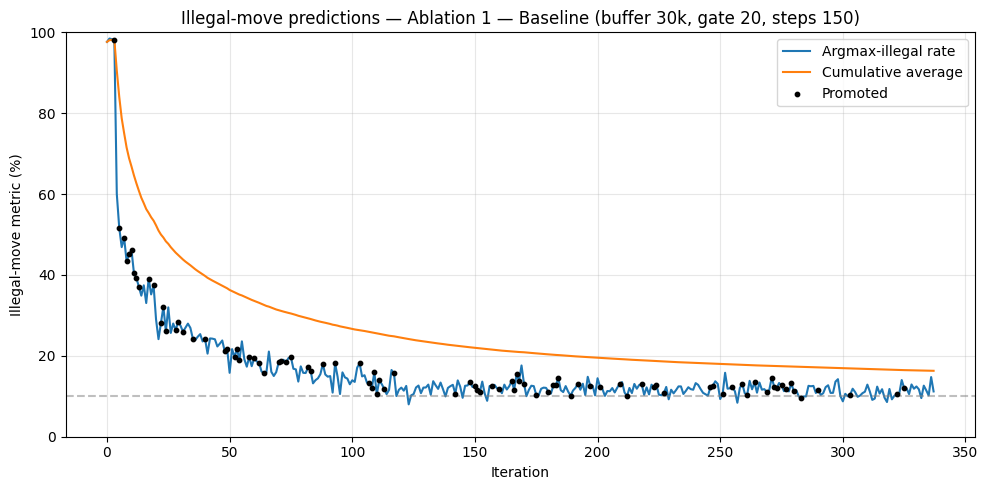

  iters=338 last=337 final_rate=11.20% promotions=91


In [2]:
plot_illegal('results/abl1_baseline/run.log', 'Ablation 1 — Baseline (buffer 30k, gate 20, steps 150)')

## Ablation 2 — Buffer 10k

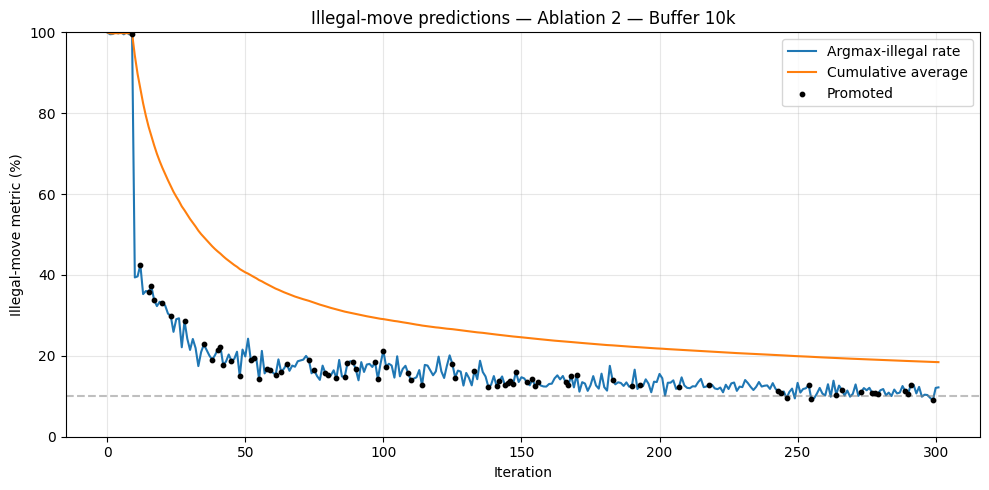

  iters=302 last=301 final_rate=12.20% promotions=78


In [3]:
plot_illegal('results/abl2_buffer_10k/run.log', 'Ablation 2 — Buffer 10k')

## Ablation 3 — Buffer 3k

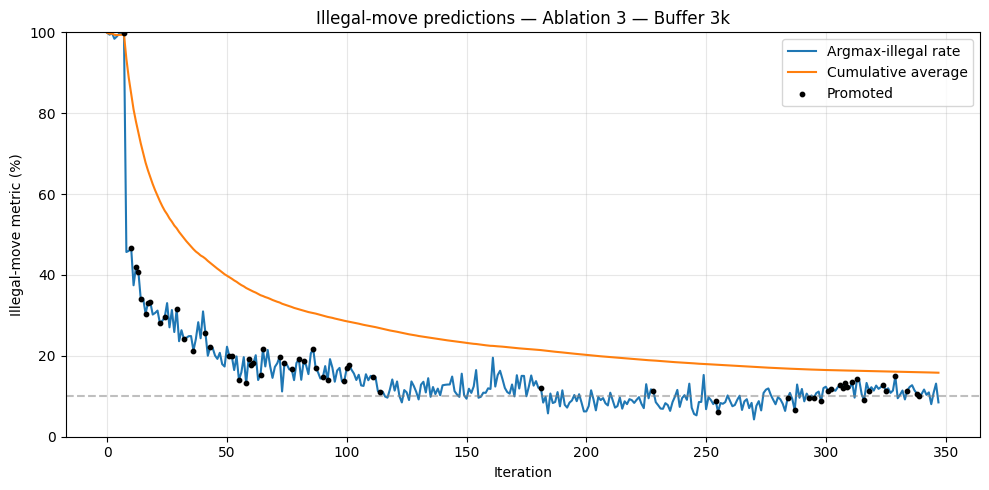

  iters=348 last=347 final_rate=8.49% promotions=63


In [4]:
plot_illegal('results/abl3_buffer_3k/run.log', 'Ablation 3 — Buffer 3k')

## Ablation 4 — Gate 50 games

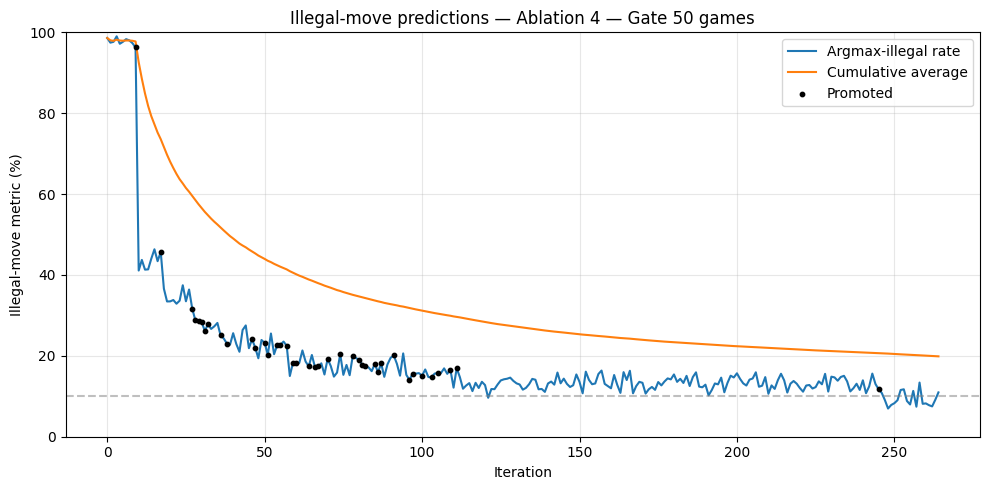

  iters=265 last=264 final_rate=10.96% promotions=40


In [5]:
plot_illegal('results/abl4_gate_50/run.log', 'Ablation 4 — Gate 50 games')

## Ablation 5 — Gate 120 games

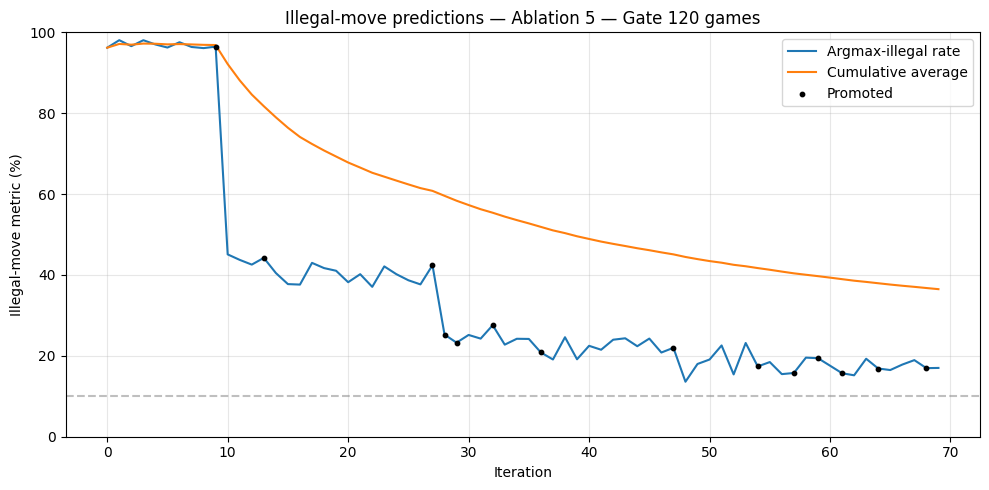

  iters=70 last=69 final_rate=17.01% promotions=14


In [6]:
plot_illegal('results/abl5_gate_120/run.log', 'Ablation 5 — Gate 120 games')

## Ablation 6 — Steps 50/iter

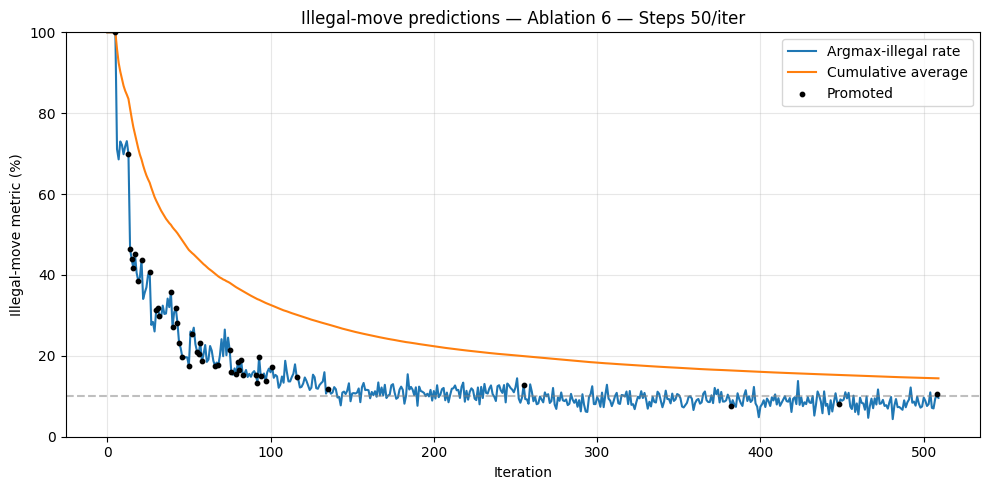

  iters=510 last=509 final_rate=9.60% promotions=45


In [7]:
plot_illegal('results/abl6_steps_50/run.log', 'Ablation 6 — Steps 50/iter')

## Ablation 7 — Steps 100/iter

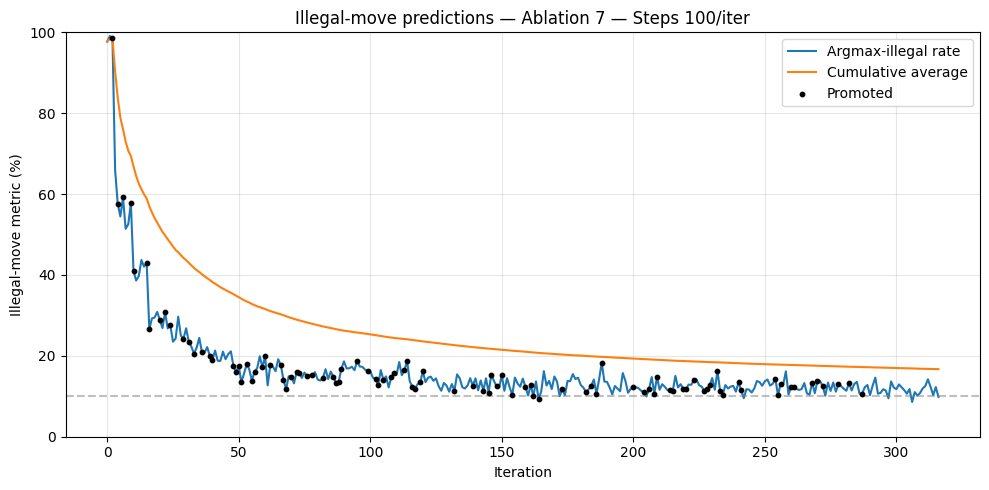

  iters=317 last=316 final_rate=9.84% promotions=98


In [8]:
plot_illegal('results/abl7_steps_100/run.log', 'Ablation 7 — Steps 100/iter')

## SGD gate run (long baseline, ~890 iters)

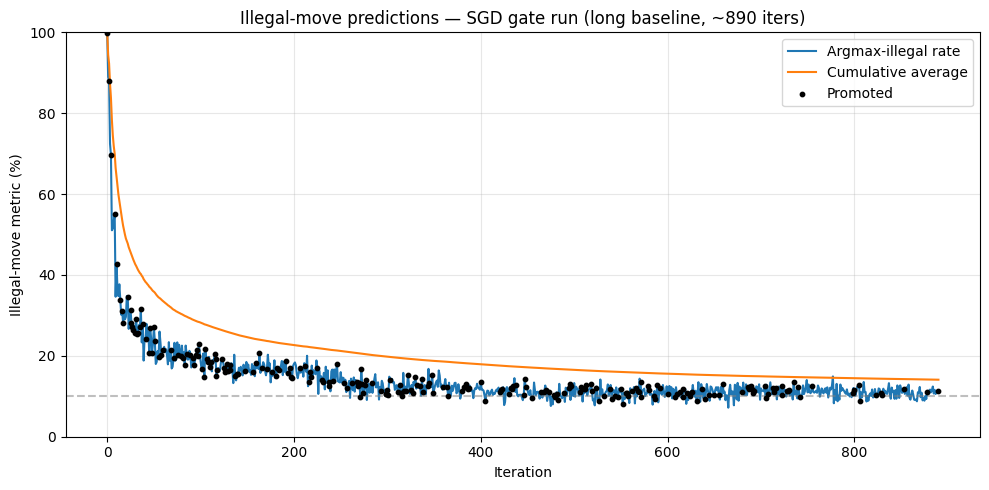

  iters=891 last=890 final_rate=11.33% promotions=242


In [9]:
plot_illegal('results/sgd_gate_run/run.log', 'SGD gate run (long baseline, ~890 iters)')